# (노트) 루나랜더

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [딥러닝]

In [1]:
#!pip install gym[Box_2D] Box2D box2d-py gym[box2d]

In [2]:
import gym
#from gym.wrappers import Monitor
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import base64, io

import numpy as np
from collections import deque, namedtuple

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display 
import glob

In [3]:
env = gym.make('LunarLander-v2')
env.seed(0)
print('State shape: ', env.observation_space.shape)
print('Number of actions: ', env.action_space.n)

State shape:  (8,)
Number of actions:  4


/home/cgb4/anaconda3/envs/py37/lib/python3.7/site-packages/gym/core.py:330: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  "Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future."
/home/cgb4/anaconda3/envs/py37/lib/python3.7/site-packages/gym/wrappers/step_api_compatibility.py:40: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  "Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future."
/h

In [4]:
net = torch.nn.Sequential(
    torch.nn.Linear(in_features=8, out_features=128),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=128, out_features=64),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=64, out_features=32),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=32, out_features=4)
)
net

Sequential(
  (0): Linear(in_features=8, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=4, bias=True)
)

In [5]:
class ReplayBuffer:
    def __init__(self, action_size, buffer_size, batch_size, seed):
        self.action_size = action_size
        self.memory = deque(maxlen=buffer_size)  
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])
        self.seed = random.seed(seed)
    
    def add(self, state, action, reward, next_state, done):
        """Add a new experience to memory."""
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)
    
    def sample(self):
        """Randomly sample a batch of experiences from memory."""
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float()
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long()
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float()
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float()
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float()
        
        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        """Return the current size of internal memory."""
        return len(self.memory)

In [9]:
class Agent():
    def __init__(self):
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_features=8, out_features=128),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=64, out_features=32),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=32, out_features=4)
        )
        
        self.optimizer = optim.Adam(self.net.parameters(), lr=0.0001)
        self.replaybuffer = ReplayBuffer(4, 100000, 128, 0)
        self.t_step = 0
    
    def step(self, state, action, reward, next_state, done):
        self.replaybuffer.add(state, action, reward, next_state, done)
        
        if len(self.replaybuffer) > 128:
            states, actions, rewards, next_states, dones = self.replaybuffer.sample()
            q_targets_next = self.net(next_states).detach().max(1)[0].reshape(-1,1)
            q_targets = rewards + 0.99 * q_targets_next * (1 - dones)
            q_expected = self.net(states).gather(1, actions)
            loss = F.mse_loss(q_expected, q_targets)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()            


    def act(self, state, eps=0.):
        state = torch.from_numpy(state).float().unsqueeze(0)
        self.net.eval()
        with torch.no_grad():
            action_values = self.net(state)
        self.net.train()
        if random.random() > eps:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(4))

In [10]:
n_episodes=2000
max_t=1000
eps_start=1
eps_end=0.01
eps_decay=0.995

In [11]:
agent = Agent()

In [12]:
scores = []                        # list containing scores from each episode
scores_window = deque(maxlen=100)  # last 100 scores
eps = eps_start                    # initialize epsilon
for i_episode in range(1, n_episodes+1):
    state = env.reset()
    score = 0
    for t in range(max_t):
        ############################### TODO: YOUR CODE BELOW ##############################
        ## STEP1: action을 agent로부터 뽑습니다.
        action = agent.act(state, eps)
        
        ## STEP2: env.step()을 사용해서 원하는 정보를 뽑습니다.
        next_state, reward, done, _ = env.step(action)
        #reward = reward - 1/20*np.abs(t/50-15)
        
        ## STEP3: 뽑아낸 정보를 바탕으로 agent를 학습시킵니다.
        agent.step(state, action, reward, next_state, done)
        
        ## STEP4: 다음 상태로 갱신시킵니다
        state = next_state
        
        ## STEP5: score를 정의해주세요.
        score += reward
        
        ################################# END OF YOUR CODE #################################
        if done:
            break 
    scores_window.append(score)       # save most recent score
    scores.append(score)              # save most recent score
    eps = max(eps_end, eps_decay*eps) # decrease epsilon
    print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)), end="")
    if i_episode % 100 == 0:
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)))
    #if np.mean(scores_window)>=200.0:
    #print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_window)))
    #torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
    #break

Episode 100	Average Score: -137.69
Episode 200	Average Score: -61.316
Episode 300	Average Score: 91.399
Episode 400	Average Score: 210.08
Episode 500	Average Score: 234.90
Episode 600	Average Score: 243.59
Episode 700	Average Score: 245.44
Episode 800	Average Score: 268.19
Episode 900	Average Score: 256.04
Episode 1000	Average Score: 254.07
Episode 1100	Average Score: 266.78
Episode 1200	Average Score: 261.66
Episode 1300	Average Score: 276.66
Episode 1400	Average Score: 279.87
Episode 1500	Average Score: 273.36
Episode 1600	Average Score: 271.57
Episode 1700	Average Score: 278.77
Episode 1800	Average Score: 265.23
Episode 1900	Average Score: 268.95
Episode 2000	Average Score: 279.91


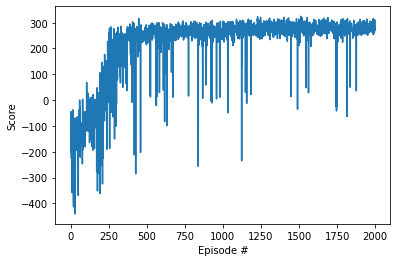

In [13]:
# plot the scores
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()